In [19]:
import pandas as pd

df = pd.read_csv("../dataset/supplier_quotes_synthetic_realistic.csv")

required_columns = [
    "quoteId",
    "supplierName",
    "materialName",
    "unitPrice",
    "quantity",
    "totalPrice",
    "deliveryDays",
    "region",
    "quoteDate",
    "fileType",
    "riskStatus",
    "riskReason"
]

print(df)



    quoteId      supplierName materialName  unitPrice  quantity  totalPrice  \
0    Q00522           BuildCo         Wood      90.06       203    18281.71   
1    Q00738        NorthSteel       Copper    8525.51       102   869602.09   
2    Q00741      BudgetSource       Copper    6038.54       144   869550.11   
3    Q00661      BudgetSource     Aluminum    1233.13       330   406932.05   
4    Q00412       RapidSupply     Concrete     168.94       956   161503.93   
..      ...               ...          ...        ...       ...         ...   
995  Q00107     XYZ Materials        Steel    1056.43       545   575755.24   
996  Q00271   Maple Materials     Concrete     218.53       413    90254.80   
997  Q00861      BudgetSource     Concrete     271.84      1283   348768.66   
998  Q00436  Prime Industrial         Wood      80.27       262    21032.00   
999  Q00103      BudgetSource        Steel     870.64       145   126242.26   

     deliveryDays    region   quoteDate fileType ri

In [20]:
# Dataset Info

print("\n1. BASIC DATASET INFORMATION")
print("-" * 60)

print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

print("\nColumn names:")
for col in df.columns:
    print(f"- {col}")

print("\nData types:")
print(df.dtypes)



1. BASIC DATASET INFORMATION
------------------------------------------------------------
Total rows: 1000
Total columns: 12

Column names:
- quoteId
- supplierName
- materialName
- unitPrice
- quantity
- totalPrice
- deliveryDays
- region
- quoteDate
- fileType
- riskStatus
- riskReason

Data types:
quoteId          object
supplierName     object
materialName     object
unitPrice       float64
quantity          int64
totalPrice      float64
deliveryDays      int64
region           object
quoteDate        object
fileType         object
riskStatus       object
riskReason       object
dtype: object


In [21]:
# 3. column Check
print("\n2. REQUIRED COLUMNS CHECK")
print("-" * 60)

required_columns = [
    "quoteId",
    "supplierName",
    "materialName",
    "unitPrice",
    "quantity",
    "totalPrice",
    "deliveryDays",
    "region",
    "quoteDate",
    "fileType",
    "riskStatus",
    "riskReason"
]

existing_columns = list(df.columns)
missing_columns = [col for col in required_columns if col not in existing_columns]
extra_columns = [col for col in existing_columns if col not in required_columns]

print(f"Required columns expected: {len(required_columns)}")
print(f"Columns found in dataset: {len(existing_columns)}")
print(f"Missing required columns count: {len(missing_columns)}")
print(f"Extra columns count: {len(extra_columns)}")

if missing_columns:
    print("\nMissing columns:")
    for col in missing_columns:
        print(f"- {col}")

if extra_columns:
    print("\nExtra columns:")
    for col in extra_columns:
        print(f"- {col}")


2. REQUIRED COLUMNS CHECK
------------------------------------------------------------
Required columns expected: 12
Columns found in dataset: 12
Missing required columns count: 0
Extra columns count: 0


In [22]:
#  Missing Value Analysis
print("\n3. MISSING VALUES ANALYSIS")
print("-" * 60)

missing_by_column = df.isnull().sum()
total_missing = missing_by_column.sum()

print(f"Total missing values in dataset: {total_missing}")

print("\nMissing values by column:")
print(missing_by_column)

missing_percentage = (missing_by_column / len(df)) * 100

print("\nMissing percentage by column:")
print(missing_percentage.round(2))


3. MISSING VALUES ANALYSIS
------------------------------------------------------------
Total missing values in dataset: 0

Missing values by column:
quoteId         0
supplierName    0
materialName    0
unitPrice       0
quantity        0
totalPrice      0
deliveryDays    0
region          0
quoteDate       0
fileType        0
riskStatus      0
riskReason      0
dtype: int64

Missing percentage by column:
quoteId         0.0
supplierName    0.0
materialName    0.0
unitPrice       0.0
quantity        0.0
totalPrice      0.0
deliveryDays    0.0
region          0.0
quoteDate       0.0
fileType        0.0
riskStatus      0.0
riskReason      0.0
dtype: float64


In [23]:
print("\n4. TARGET COLUMN: riskStatus")
print("-" * 60)

risk_counts = df["riskStatus"].value_counts()
risk_percentages = df["riskStatus"].value_counts(normalize=True) * 100

print("Risk status count:")
print(risk_counts)

print("\nRisk status percentage:")
print(risk_percentages.round(2))

normal_count = risk_counts.get("Normal", 0)
anomaly_count = risk_counts.get("Anomaly", 0)

print(f"\nNormal rows: {normal_count}")
print(f"Anomaly rows: {anomaly_count}")
print(f"Normal-to-anomaly ratio: {normal_count}:{anomaly_count}")



4. TARGET COLUMN: riskStatus
------------------------------------------------------------
Risk status count:
riskStatus
Normal     750
Anomaly    250
Name: count, dtype: int64

Risk status percentage:
riskStatus
Normal     75.0
Anomaly    25.0
Name: proportion, dtype: float64

Normal rows: 750
Anomaly rows: 250
Normal-to-anomaly ratio: 750:250


In [24]:
# Material category distribution

print("\n5. MATERIAL CATEGORY DISTRIBUTION")
print("-" * 60)

material_counts = df["materialName"].value_counts()
material_percentages = df["materialName"].value_counts(normalize=True) * 100

print("Material counts:")
print(material_counts)

print("\nMaterial percentages:")
print(material_percentages.round(2))

print(f"\nNumber of unique materials: {df['materialName'].nunique()}")


5. MATERIAL CATEGORY DISTRIBUTION
------------------------------------------------------------
Material counts:
materialName
Steel       300
Concrete    250
Wood        200
Aluminum    150
Copper      100
Name: count, dtype: int64

Material percentages:
materialName
Steel       30.0
Concrete    25.0
Wood        20.0
Aluminum    15.0
Copper      10.0
Name: proportion, dtype: float64

Number of unique materials: 5


In [25]:
# Supplier distribution


print("\n6. SUPPLIER DISTRIBUTION")
print("-" * 60)

supplier_counts = df["supplierName"].value_counts()

print(f"Number of unique suppliers: {df['supplierName'].nunique()}")
print("\nSupplier quote counts:")
print(supplier_counts)


6. SUPPLIER DISTRIBUTION
------------------------------------------------------------
Number of unique suppliers: 8

Supplier quote counts:
supplierName
XYZ Materials       136
Maple Materials     132
BudgetSource        129
NorthSteel          124
BuildCo             123
RapidSupply         119
Prime Industrial    119
ABC Suppliers       118
Name: count, dtype: int64


In [26]:
# Region distribution

print("\n7. REGION DISTRIBUTION")
print("-" * 60)

region_counts = df["region"].value_counts()

print(f"Number of unique regions: {df['region'].nunique()}")
print("\nRegion counts:")
print(region_counts)



7. REGION DISTRIBUTION
------------------------------------------------------------
Number of unique regions: 4

Region counts:
region
New York    280
Quebec      251
Michigan    237
Ontario     232
Name: count, dtype: int64


In [27]:
# File type distribution


print("\n8. FILE TYPE DISTRIBUTION")
print("-" * 60)

file_type_counts = df["fileType"].value_counts()

print(f"Number of unique file types: {df['fileType'].nunique()}")
print("\nFile type counts:")
print(file_type_counts)


8. FILE TYPE DISTRIBUTION
------------------------------------------------------------
Number of unique file types: 3

File type counts:
fileType
Excel    355
CSV      336
PDF      309
Name: count, dtype: int64


In [28]:
# Numeric summary


print("\n9. NUMERIC FEATURE SUMMARY")
print("-" * 60)

numeric_columns = ["unitPrice", "quantity", "totalPrice", "deliveryDays"]

print(df[numeric_columns].describe().round(2))



9. NUMERIC FEATURE SUMMARY
------------------------------------------------------------
       unitPrice  quantity  totalPrice  deliveryDays
count    1000.00   1000.00     1000.00       1000.00
mean     1531.13    473.47   314363.75         14.33
std      2709.33    363.37   348360.84         12.07
min        19.02     11.00     5393.51          3.00
25%       162.50    196.00    77150.35          8.00
50%       832.24    361.00   210253.46         11.00
75%      1432.62    658.00   427228.90         15.00
max     18291.51   1493.00  2872328.87         65.00


In [29]:
# Check total price calculation


print("\n10. TOTAL PRICE VALIDATION")
print("-" * 60)

df["calculatedTotalPrice"] = (df["unitPrice"] * df["quantity"]).round(2)
df["totalPriceDifference"] = (df["totalPrice"] - df["calculatedTotalPrice"]).round(2)

incorrect_total_price_rows = df[df["totalPriceDifference"] != 0]

print(f"Rows with incorrect totalPrice: {len(incorrect_total_price_rows)}")
print(f"Maximum totalPrice difference: {df['totalPriceDifference'].abs().max()}")

if len(incorrect_total_price_rows) > 0:
    print("\nSample incorrect totalPrice rows:")
    print(incorrect_total_price_rows.head())


10. TOTAL PRICE VALIDATION
------------------------------------------------------------
Rows with incorrect totalPrice: 995
Maximum totalPrice difference: 6.79

Sample incorrect totalPrice rows:
  quoteId  supplierName materialName  unitPrice  quantity  totalPrice  \
0  Q00522       BuildCo         Wood      90.06       203    18281.71   
1  Q00738    NorthSteel       Copper    8525.51       102   869602.09   
2  Q00741  BudgetSource       Copper    6038.54       144   869550.11   
3  Q00661  BudgetSource     Aluminum    1233.13       330   406932.05   
4  Q00412   RapidSupply     Concrete     168.94       956   161503.93   

   deliveryDays    region   quoteDate fileType riskStatus  \
0             7  Michigan  2025-03-22      PDF     Normal   
1            23  Michigan  2025-05-19      CSV     Normal   
2             9   Ontario  2025-01-14      CSV     Normal   
3            15   Ontario  2025-03-31    Excel     Normal   
4            12    Quebec  2025-09-19      CSV     Normal   

In [30]:
# Risk status by material


print("\n11. RISK STATUS BY MATERIAL")
print("-" * 60)

risk_by_material = pd.crosstab(df["materialName"], df["riskStatus"])

print(risk_by_material)

print("\nRisk status by material percentage:")
risk_by_material_percent = pd.crosstab(
    df["materialName"],
    df["riskStatus"],
    normalize="index"
) * 100

print(risk_by_material_percent.round(2))


11. RISK STATUS BY MATERIAL
------------------------------------------------------------
riskStatus    Anomaly  Normal
materialName                 
Aluminum           38     112
Concrete           62     188
Copper             25      75
Steel              75     225
Wood               50     150

Risk status by material percentage:
riskStatus    Anomaly  Normal
materialName                 
Aluminum        25.33   74.67
Concrete        24.80   75.20
Copper          25.00   75.00
Steel           25.00   75.00
Wood            25.00   75.00


In [31]:
# Train/test split check

from sklearn.model_selection import train_test_split

recommended_features = [
    "materialName",
    "unitPrice",
    "quantity",
    "deliveryDays",
    "region"
]

print("\n16. TRAIN/TEST SPLIT CHECK")
print("-" * 60)

X = df[recommended_features]
y = df["riskStatus"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

print("\nTraining target distribution:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))



16. TRAIN/TEST SPLIT CHECK
------------------------------------------------------------
Training rows: 800
Testing rows: 200

Training target distribution:
riskStatus
Normal     600
Anomaly    200
Name: count, dtype: int64
riskStatus
Normal     75.0
Anomaly    25.0
Name: proportion, dtype: float64

Testing target distribution:
riskStatus
Normal     150
Anomaly     50
Name: count, dtype: int64
riskStatus
Normal     75.0
Anomaly    25.0
Name: proportion, dtype: float64


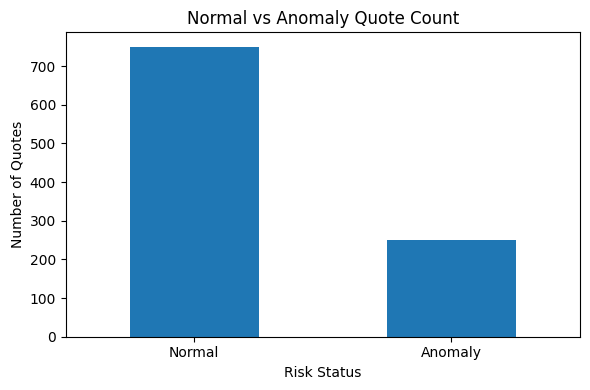

In [32]:
# Graph 1: Normal vs Anomaly count
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
risk_counts.plot(kind="bar")
plt.title("Normal vs Anomaly Quote Count")
plt.xlabel("Risk Status")
plt.ylabel("Number of Quotes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../graphs/graph_1_risk_status_count.png", dpi=300)
plt.show()


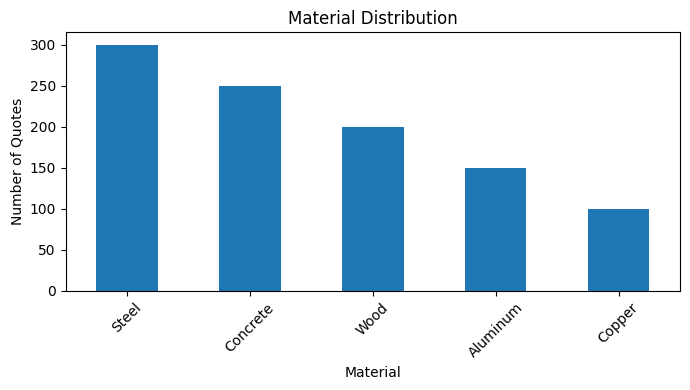

In [33]:
# Graph 2: Material distribution
plt.figure(figsize=(7, 4))
material_counts.plot(kind="bar")
plt.title("Material Distribution")
plt.xlabel("Material")
plt.ylabel("Number of Quotes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../graphs/graph_2_material_distribution.png", dpi=300)
plt.show()

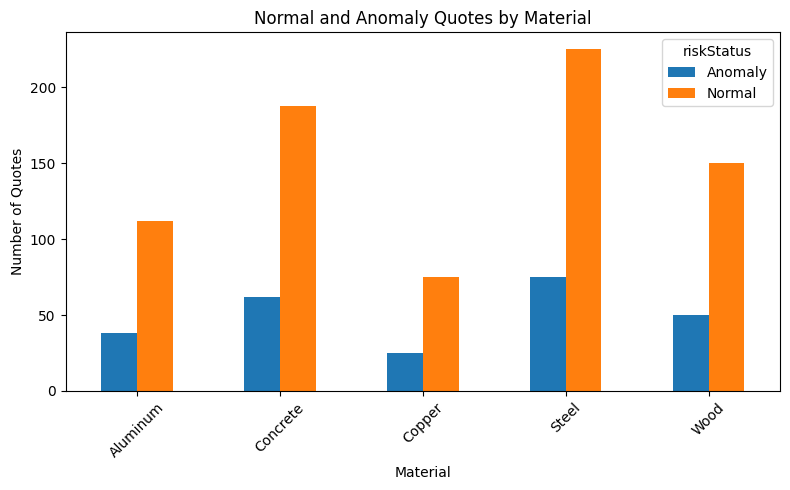

In [34]:
# Graph 3: Risk status by material
risk_by_material.plot(kind="bar", figsize=(8, 5))
plt.title("Normal and Anomaly Quotes by Material")
plt.xlabel("Material")
plt.ylabel("Number of Quotes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../graphs/graph_3_risk_by_material.png", dpi=300)
plt.show()

/var/folders/p5/g7gd_mwd10b4r42w413kr3rm0000gn/T/ipykernel_97863/1240761835.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(unit_price_data, labels=materials)


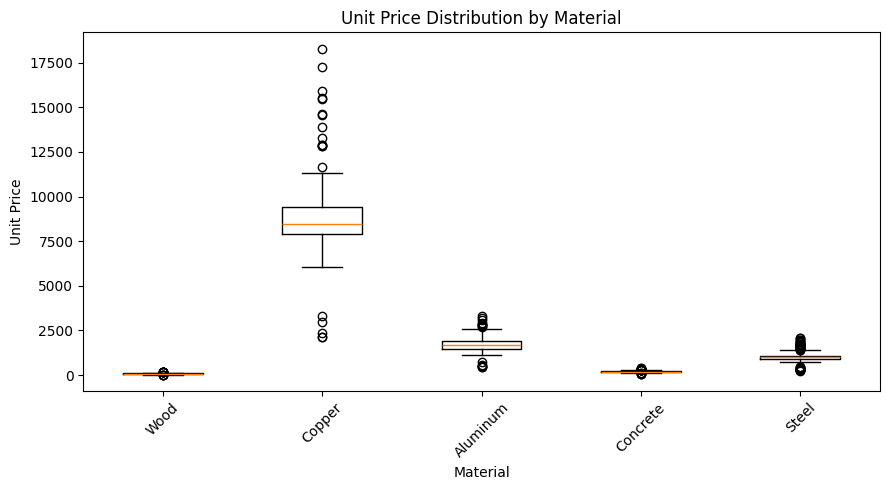

In [35]:
# Graph 4: Unit price distribution by material
materials = df["materialName"].unique()
unit_price_data = [
    df[df["materialName"] == material]["unitPrice"]
    for material in materials
]

plt.figure(figsize=(9, 5))
plt.boxplot(unit_price_data, labels=materials)
plt.title("Unit Price Distribution by Material")
plt.xlabel("Material")
plt.ylabel("Unit Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../graphs/graph_4_unit_price_by_material.png", dpi=300)
plt.show()


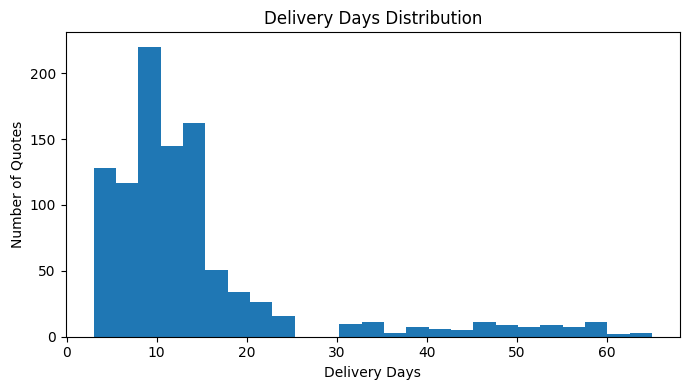

In [36]:
# Graph 5: Delivery days distribution
plt.figure(figsize=(7, 4))
plt.hist(df["deliveryDays"], bins=25)
plt.title("Delivery Days Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Quotes")
plt.tight_layout()
plt.savefig("../graphs/graph_5_delivery_days_distribution.png", dpi=300)
plt.show()
